In [29]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [30]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [31]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,2.423214,0.093652,0.941980,-2.081657,-0.614392,1
1,0.010415,-0.788096,-1.858857,0.009446,2.787097,1
2,1.423957,-1.673623,-2.129939,0.213030,2.456863,0
3,0.540738,-1.558971,0.268495,0.260197,1.777785,0
4,1.689815,-0.653418,0.037565,-1.973178,-0.471374,1


In [32]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [33]:
# function for feature sampling
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [34]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [35]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\Pavilion\AppData\Local\Temp\ipykernel_8944\516260379.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [36]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\Pavilion\AppData\Local\Temp\ipykernel_8944\516260379.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [37]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Pavilion\AppData\Local\Temp\ipykernel_8944\516260379.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [38]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col3', 'target'], dtype='object')
Index(['col5', 'col1', 'target'], dtype='object')
Index(['col4', 'col2', 'target'], dtype='object')


In [39]:
df3

,col4,col2,target
61,0.818952,0.412136,0
78,-1.057403,-1.955451,1
38,-0.652713,-1.871520,1
12,-0.654676,0.436146,1
97,-2.339882,-0.185931,1
19,1.705684,-1.452117,0
96,-1.934498,-0.569142,1
33,1.997745,-2.197248,0
98,2.646940,1.609226,0
55,2.076682,-4.275110,0


In [40]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [41]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [42]:
from sklearn.tree import plot_tree

[Text(0.4583333333333333, 0.9166666666666666, 'x[0] <= -0.024\ngini = 0.461\nsamples = 50\nvalue = [32, 18]'),
 Text(0.16666666666666666, 0.75, 'x[1] <= -1.28\ngini = 0.128\nsamples = 29\nvalue = [27, 2]'),
 Text(0.3125, 0.8333333333333333, 'True  '),
 Text(0.08333333333333333, 0.5833333333333334, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.5833333333333334, 'x[1] <= -0.309\ngini = 0.069\nsamples = 28\nvalue = [27, 1]'),
 Text(0.16666666666666666, 0.4166666666666667, 'x[1] <= -0.467\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.08333333333333333, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 25\nvalue = [25, 0]'),
 Text(0.75, 0.75, 'x[0] <= 1.173\ngini = 0.363\nsamples = 21\nvalue = [5, 16]'),
 Text(0.6041666666666666, 0.8333333333333333, '  False'),
 Text(0.6666666666666666, 0.5833333333333334, 'x[1] <= 0.109\ngini = 0.473\nsample

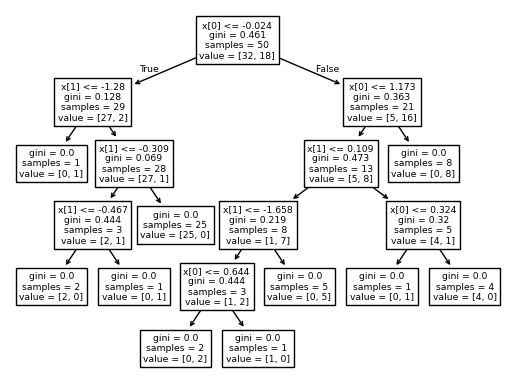

In [43]:
plot_tree(clf1)

[Text(0.4444444444444444, 0.9, 'x[1] <= -0.024\ngini = 0.461\nsamples = 50\nvalue = [18, 32]'),
 Text(0.2222222222222222, 0.7, 'x[0] <= -0.672\ngini = 0.188\nsamples = 19\nvalue = [17, 2]'),
 Text(0.3333333333333333, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5, 'x[0] <= -0.105\ngini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.2222222222222222, 0.3, 'x[0] <= -0.201\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.6666666666666666, 0.7, 'x[1] <= 1.097\ngini = 0.062\nsamples = 31\nvalue = [1, 30]'),
 Text(0.5555555555555556, 0.8, '  False'),
 Text(0.5555555555555556, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.7777777777777778, 0.5, 'x[1] <= 1.147\ngini = 0.165\nsa

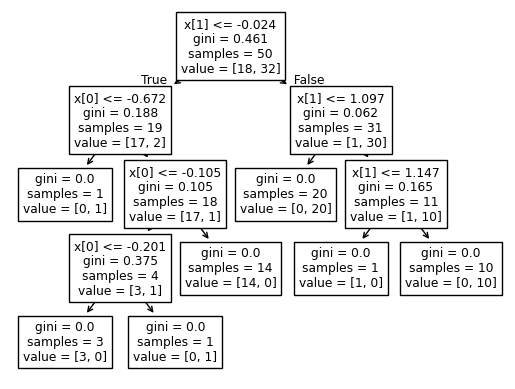

In [44]:
plot_tree(clf2)

[Text(0.5555555555555556, 0.9375, 'x[0] <= 0.428\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.4444444444444444, 0.8125, 'x[1] <= -2.412\ngini = 0.213\nsamples = 33\nvalue = [4, 29]'),
 Text(0.5, 0.875, 'True  '),
 Text(0.2222222222222222, 0.6875, 'x[0] <= -0.052\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1111111111111111, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.6875, 'x[1] <= -1.151\ngini = 0.175\nsamples = 31\nvalue = [3, 28]'),
 Text(0.5555555555555556, 0.5625, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.7777777777777778, 0.5625, 'x[0] <= -0.569\ngini = 0.266\nsamples = 19\nvalue = [3, 16]'),
 Text(0.6666666666666666, 0.4375, 'x[1] <= -1.004\ngini = 0.198\nsamples = 18\nvalue = [2, 16]'),
 Text(0.5555555555555556, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7777777777777778, 0.3125, 'x[1] <= -0.802\ngini = 0.111\nsamp

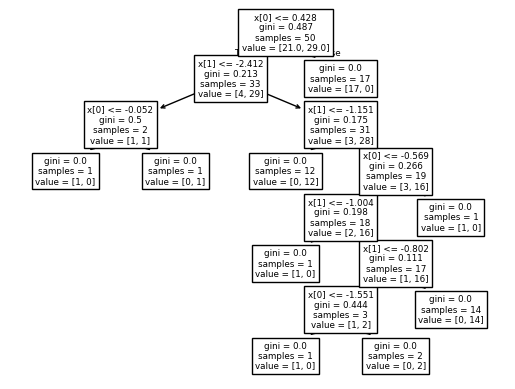

In [45]:
plot_tree(clf3)

In [46]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Pavilion\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [47]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Pavilion\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [48]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Pavilion\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [49]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
66,-0.785134,-1.106573,-2.402026,-2.258331,-0.739349,1
92,-0.033876,-1.358157,3.439302,0.805766,1.282201,0
96,0.544923,-0.569142,-0.610735,-1.934498,-0.089031,1
79,-1.024022,-2.536127,2.128812,0.409223,-0.342565,0
69,-1.225734,-2.729151,-2.251006,0.404376,3.756063,1
2,1.423957,-1.673623,-2.129939,0.213030,2.456863,0
72,1.005027,-1.663840,-1.628026,0.678043,3.435867,1
60,2.530832,-2.421129,-0.918367,-1.288587,-0.257333,1
36,-0.517065,-2.112793,0.508107,-0.435067,0.586647,0
89,2.077372,-1.653651,-1.637565,0.438252,2.515720,1
